In [2]:
from bs4 import BeautifulSoup
import re
import emoji
import string
import contractions
from symspellpy import SymSpell
import pkg_resources
import nltk
    
resources = [
        'punkt',
        'punkt_tab',
        'stopwords',
        'wordnet',
        'omw-1.4',
        'averaged_perceptron_tagger_eng'
    ]
    
for resource in resources:
        nltk.download(resource)
    
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Think\AppData\Local\Temp\ipykernel_11488\1736052220.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 

In [2]:
def process_data(text):
       
    text = BeautifulSoup(text, "html.parser").text
          
    text = contractions.fix(text)
     
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'\+?\d[\d\s-]{8,}\d', '', text)
       
    text = emoji.replace_emoji(text, replace='')
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    text = text.lower()
    
    dictionary_path = pkg_resources.resource_filename(
        "symspellpy",
        "frequency_dictionary_en_82_765.txt"
    )
    
    # Create object
    sym_spell = SymSpell(max_dictionary_edit_distance=2)
    
    # Load dictionary
    dictionary_path = pkg_resources.resource_filename(
        "symspellpy",
        "frequency_dictionary_en_82_765.txt"
    )
    
    sym_spell.load_dictionary(
        dictionary_path,
        term_index=0,
        count_index=1
    )
    
    
    suggestions = sym_spell.lookup_compound(
        text,
        max_edit_distance=2
    )
    
    text=suggestions[0].term
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    
    tokens = [word for word in tokens if word not in stop_words]
    
    lemmatizer = WordNetLemmatizer()
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    text = " ".join(tokens)
    
    return text

In [3]:
folder_path = r"C:\Users\Think\Desktop\anacondaaa\nlp\NLP Models\plagiarism"

documents = {}

for file in os.listdir(folder_path):
    if file.endswith(".txt"):
        file_path = os.path.join(folder_path, file)

        with open(file_path, "r", encoding="utf-8") as f:
            documents[file] = f.read()

print("Total Documents:", len(documents))

Total Documents: 2


In [8]:
processed_documents = {}
for filename, text in documents.items():
    processed_documents[filename] = process_data(text)

filename = list(documents.keys())[0]



In [5]:
print(len(processed_documents))

2


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
filenames = list(processed_documents.keys())
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_documents.values())

In [10]:
print(tfidf_matrix.shape)

(2, 373)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)
print(similarity_matrix.shape)

(2, 2)


In [14]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=filenames,
    columns=filenames
)

similarity_df = similarity_df.round(4)

similarity_df

,doc_001.txt,doc_002.txt
doc_001.txt,1.000,0.741
doc_002.txt,0.741,1.000


In [13]:
threshold = 0.70

for i in range(len(filenames)):
    for j in range(i + 1, len(filenames)):   # avoids duplicate comparisons
        score = similarity_matrix[i][j]

        if score >= threshold:
            print(f"{filenames[i]}  <-->  {filenames[j]} : {score*100:.2f}%")

doc_001.txt  <-->  doc_002.txt : 74.10%


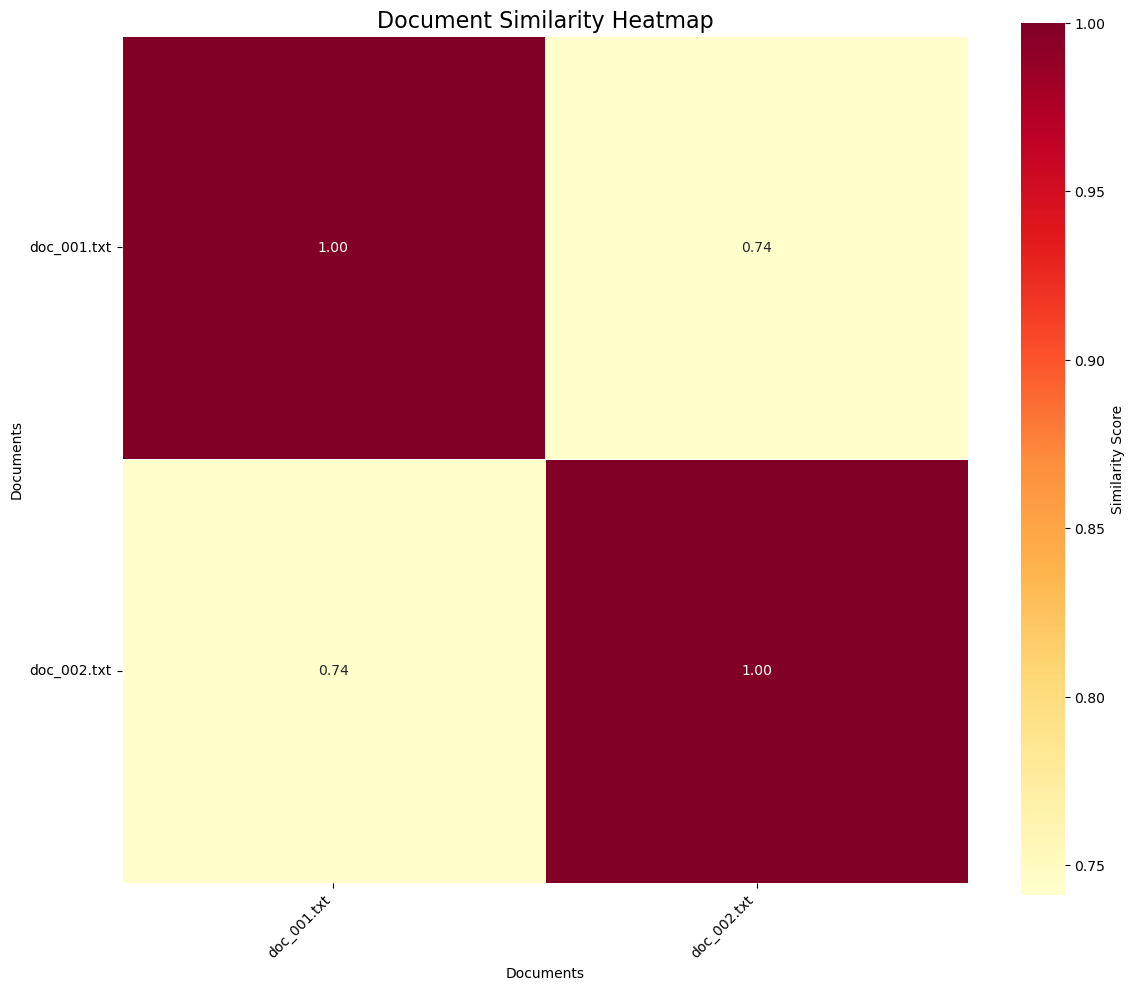

In [16]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    similarity_df,
    annot=True,          # Show similarity values
    fmt=".2f",           # Show 2 decimal places
    cmap="YlOrRd",       # Yellow → Orange → Red
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Similarity Score"}
)

plt.title("Document Similarity Heatmap", fontsize=16)
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()